# CUSTOMER CHURN PREDICTION

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
import pickle as pk

In [96]:
data=pd.read_csv('Churn_Modelling.csv')

In [97]:
data.shape

(10000, 14)

In [98]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [99]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [100]:
for col in data.columns:
    print(f"{col}: {data[col].nunique()}")

RowNumber: 10000
CustomerId: 10000
Surname: 2932
CreditScore: 460
Geography: 3
Gender: 2
Age: 70
Tenure: 11
Balance: 6382
NumOfProducts: 4
HasCrCard: 2
IsActiveMember: 2
EstimatedSalary: 9999
Exited: 2


In [101]:
for col in data.columns:
    print(f"{col}: {data[col].isnull().sum()}")

RowNumber: 0
CustomerId: 0
Surname: 0
CreditScore: 0
Geography: 0
Gender: 0
Age: 0
Tenure: 0
Balance: 0
NumOfProducts: 0
HasCrCard: 0
IsActiveMember: 0
EstimatedSalary: 0
Exited: 0


In [102]:
data = data.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [103]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [104]:
non_numeric_cols =data.select_dtypes(include=['object', 'category', 'datetime']).columns
print("Non-numeric columns:", non_numeric_cols)

Non-numeric columns: Index(['Geography', 'Gender'], dtype='object')


In [105]:
print(data["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [106]:
data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


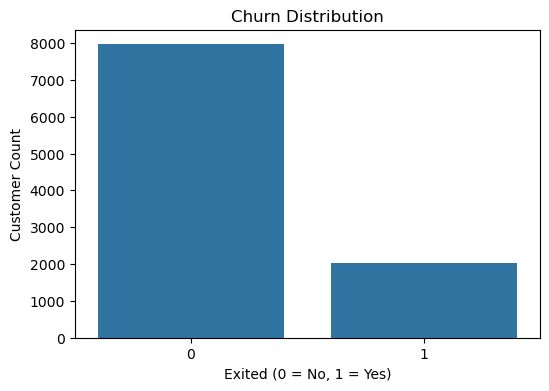

In [107]:
plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=data)
plt.title("Churn Distribution")
plt.xlabel("Exited (0 = No, 1 = Yes)")
plt.ylabel("Customer Count")
plt.show()

In [108]:
def plot_histogram(data,column_name):
    plt.figure(figsize=(5, 3))
    sns.histplot(data[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")
    
    col_mean = data[column_name].mean()
    col_median = data[column_name].median()
    
    plt.axvline(col_mean, color="red", linestyle="-", label="Mean")
    plt.axvline(col_median, color="green", linestyle="--", label="Median")
    
    plt.legend()
    plt.show()


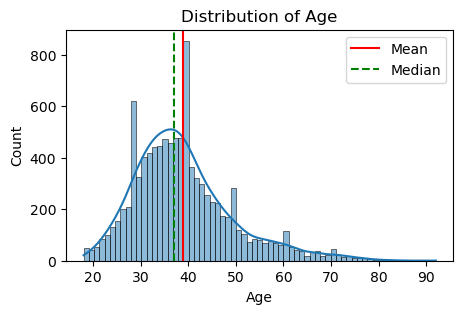

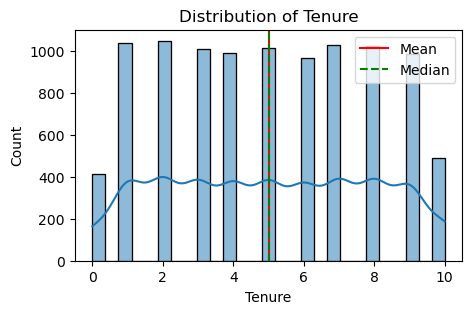

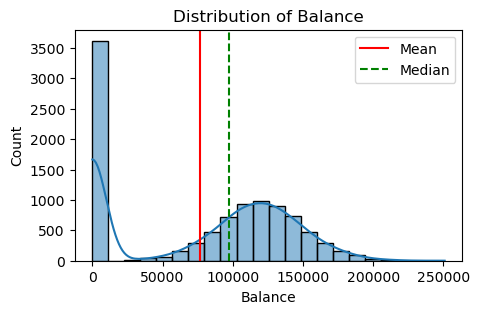

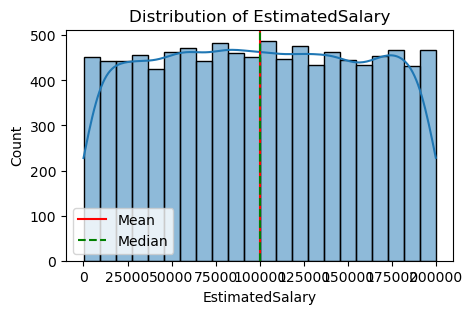

In [109]:
for col in ['Age', 'Tenure', 'Balance', 'EstimatedSalary']:
    plot_histogram(data, col)

In [110]:
def plot_boxplot(data, column_name):
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=data[column_name])
    plt.title(f"Box Plot of {column_name}")
    plt.show()

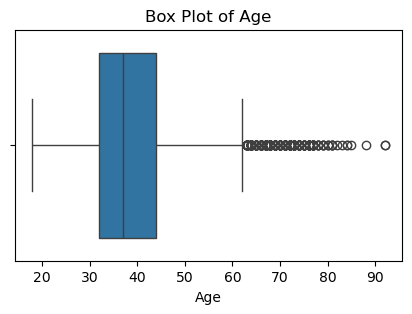

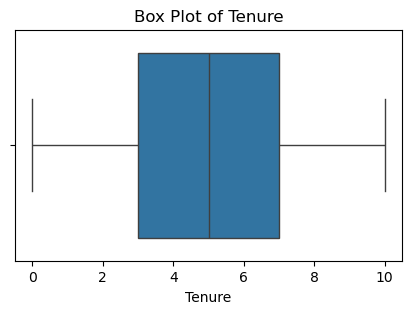

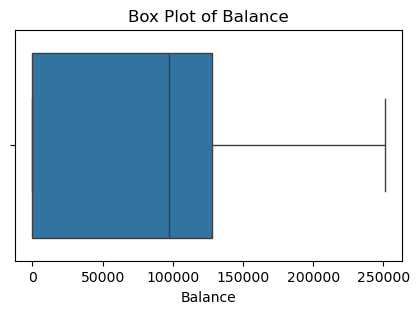

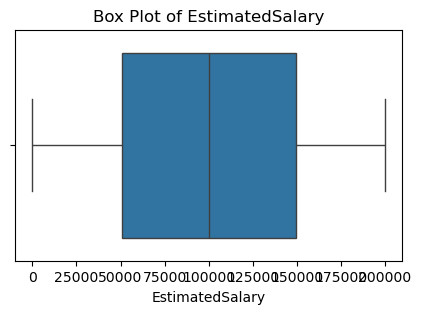

In [111]:
for col in ['Age', 'Tenure', 'Balance', 'EstimatedSalary']:
    plot_boxplot(data, col)

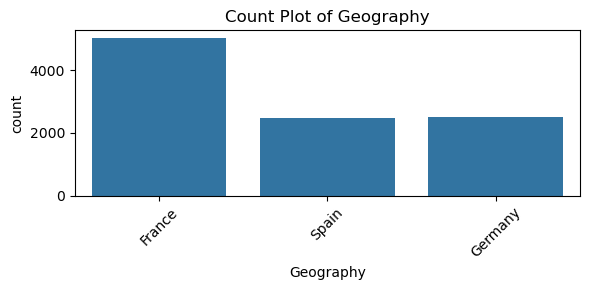

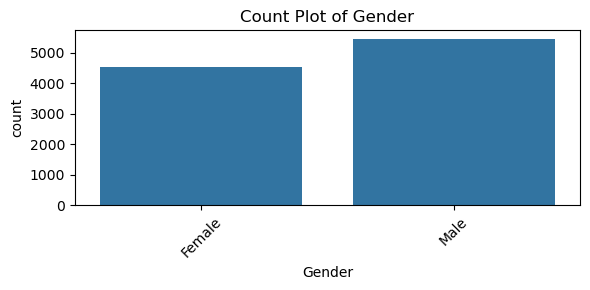

In [112]:
for col in non_numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(x=data[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [113]:
data = pd.get_dummies(data, columns=['Geography', 'Gender'], drop_first=True)

In [114]:
data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


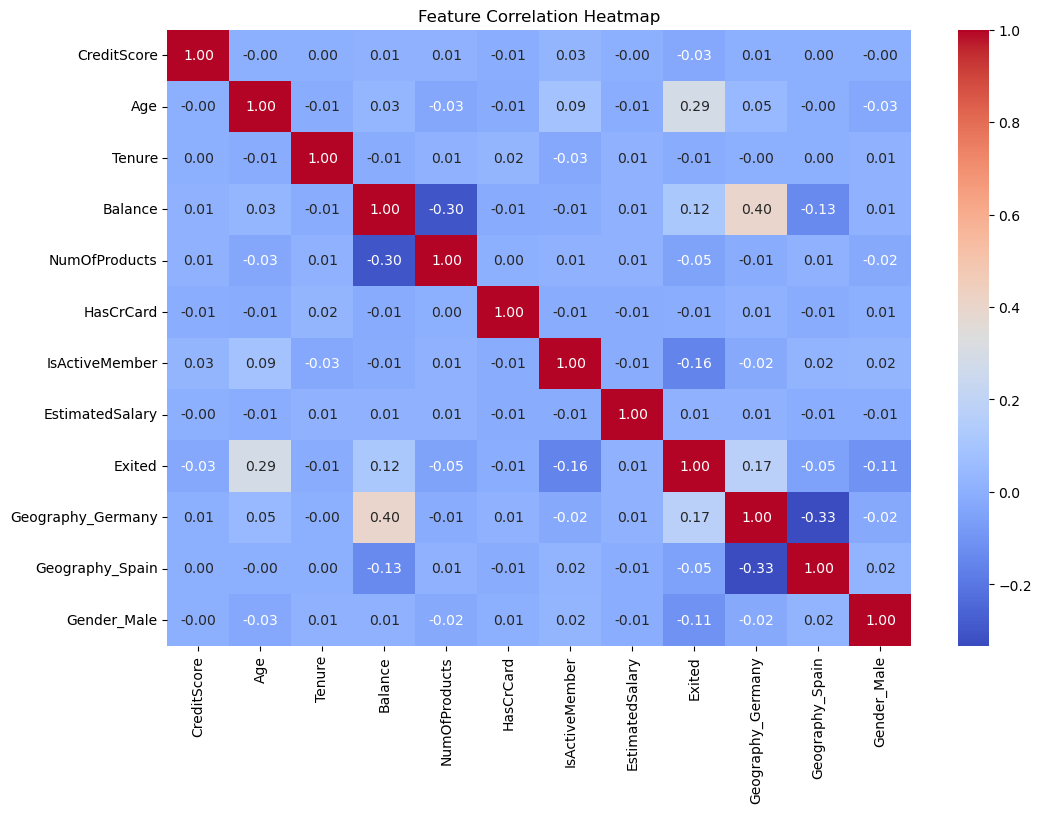

In [115]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [116]:
X = data.drop(columns=["Exited"])
y = data["Exited"]

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [118]:
print(y_train.shape)

(8000,)


In [119]:
print(y_train.value_counts())

Exited
0    6370
1    1630
Name: count, dtype: int64


In [120]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


In [121]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        # random_state=42,
        # eval_metric='logloss'
        
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

In [122]:
cv_scores = {}

for model_name, model in models.items():

    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    print(f"\nTraining {model_name}")

    scores = cross_val_score(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=skf,
        scoring='f1',
        n_jobs=-1
    )

    cv_scores[model_name] = scores
    print("F1 Scores:", scores)
    print("Mean F1 Score:", scores.mean())


Training Decision Tree
F1 Scores: [0.5019305  0.525      0.52217997 0.50909091 0.48445596]
Mean F1 Score: 0.5085314688444182

Training Random Forest
F1 Scores: [0.56637168 0.61991585 0.58953168 0.58507463 0.56104651]
Mean F1 Score: 0.5843880697755257

Training XGBoost
F1 Scores: [0.59779614 0.60834455 0.59328859 0.57834758 0.57142857]
Mean F1 Score: 0.5898410865512067


In [123]:
xgb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters:
{'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 7, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}

Best Cross Validation F1 Score:
0.5967682946840187


In [124]:
best_model.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [125]:
y_test_pred = best_model.predict(X_test) 

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))                                                                         

Accuracy: 0.8185
Confusion Matrix:
 [[1379  214]
 [ 149  258]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88      1593
           1       0.55      0.63      0.59       407

    accuracy                           0.82      2000
   macro avg       0.72      0.75      0.74      2000
weighted avg       0.83      0.82      0.82      2000



In [126]:
y_prob = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8423940118855373


In [127]:
with open("xgboost_model.pkl", "wb") as file:
    pk.dump(best_model, file)